The goal here is to answer: **Can each spatial transcriptomics spot be linked to a usable H&E image patch?**

The output should be:

`spot_id → x/y coordinate → H&E patch`

In [1]:
# Libraries for data manipulation and visualization
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# function for finding parent directory
def find_project_root(start_path=None, project_name="HistoGeneAlign"):
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()

    for p in [start_path] + list(start_path.parents):
        if p.name == project_name:
            return p

    for p in [start_path] + list(start_path.parents):
        if (p / "data").exists() and (p / "notebooks").exists():
            return p

    raise RuntimeError("Could not find project root.")

# Defining the paths
PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hest"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PATCH_DIR = PROJECT_ROOT / "data" / "patches"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
PATCH_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_ID = "TENX95"

# Defining paths for the patch H5 data and the spot metadata CSV file
PATCH_H5_PATH = RAW_DIR / "patches" / f"{SAMPLE_ID}.h5"
SPOT_METADATA_PATH = PROCESSED_DIR / f"{SAMPLE_ID}_spot_metadata_qc.csv"

# Verification of the paths
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Patch H5 exists:", PATCH_H5_PATH.exists(), PATCH_H5_PATH)
print("Spot metadata exists:", SPOT_METADATA_PATH.exists(), SPOT_METADATA_PATH)

PROJECT_ROOT: C:\Users\Hareen\Desktop\HistoGeneAlign
Patch H5 exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\patches\TENX95.h5
Spot metadata exists: True C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\TENX95_spot_metadata_qc.csv


### Loading spot metadata

In [2]:
spot_metadata = pd.read_csv(SPOT_METADATA_PATH)

print("Spot metadata shape:", spot_metadata.shape)
display(spot_metadata.head())

print("\nColumns:")
print(spot_metadata.columns.tolist())

Spot metadata shape: (11845, 12)


,sample_id,spot_id,x,y,expression_available,coordinate_available,wsi_available,patch_h5_available,library_size,detected_genes,x_thumb,y_thumb
0,TENX95,000x000,249.515782,263.81301,True,True,True,True,0,0,4.654227,4.893503
1,TENX95,000x001,720.104017,263.81301,True,True,True,True,0,0,13.432127,4.893503
2,TENX95,000x002,1190.692253,263.81301,True,True,True,True,0,0,22.210027,4.893503
3,TENX95,000x003,1661.280488,263.81301,True,True,True,True,0,0,30.987926,4.893503
4,TENX95,000x004,2131.868723,263.81301,True,True,True,True,0,0,39.765826,4.893503



Columns:
['sample_id', 'spot_id', 'x', 'y', 'expression_available', 'coordinate_available', 'wsi_available', 'patch_h5_available', 'library_size', 'detected_genes', 'x_thumb', 'y_thumb']


### Inspecting the H5 file structure

In [3]:
def print_h5_structure(h5_path):
    with h5py.File(h5_path, "r") as f:
        print("H5 file keys:")
        print(list(f.keys()))

        print("\nFull H5 structure:")

        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"DATASET | {name} | shape={obj.shape} | dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"GROUP   | {name}")

        f.visititems(visitor)

print_h5_structure(PATCH_H5_PATH)

H5 file keys:
['barcode', 'coords', 'img']

Full H5 structure:
DATASET | barcode | shape=(7592, 1) | dtype=object
DATASET | coords | shape=(7592, 2) | dtype=int64
DATASET | img | shape=(7592, 224, 224, 3) | dtype=uint8


The barcode is a string like spotID.

The coords is the coordinates, your (x,y)

The img has a (N x H x W x 3) pattern representing RGB image patches

### Automatically Identifying likely patch dataset

In [5]:
candidate_patch_datasets = []

with h5py.File(PATCH_H5_PATH, "r") as f:
    def find_patch_candidates(name, obj):
        if isinstance(obj, h5py.Dataset):
            shape = obj.shape
            dtype = obj.dtype

            if len(shape) == 4:
                candidate_patch_datasets.append({
                    "name": name,
                    "shape": shape,
                    "dtype": str(dtype)
                })

    f.visititems(find_patch_candidates)

candidate_patch_df = pd.DataFrame(candidate_patch_datasets)

print("Candidate patch datasets:")
display(candidate_patch_df)

Candidate patch datasets:


,name,shape,dtype
0,img,"(7592, 224, 224, 3)",uint8


This `img` is likely the image patch array

### Automatically identifying coordinate & ID datasets

In [6]:
candidate_coord_datasets = []
candidate_id_datasets = []

with h5py.File(PATCH_H5_PATH, "r") as f:
    def find_candidates(name, obj):
        if isinstance(obj, h5py.Dataset):
            shape = obj.shape
            dtype = obj.dtype
            lname = name.lower()

            # coordinate-like
            if (
                len(shape) == 2 and shape[1] in [2, 3, 4]
            ) or any(k in lname for k in ["coord", "position", "spatial", "location"]):
                candidate_coord_datasets.append({
                    "name": name,
                    "shape": shape,
                    "dtype": str(dtype)
                })

            # id-like
            if any(k in lname for k in ["barcode", "spot", "id", "name"]):
                candidate_id_datasets.append({
                    "name": name,
                    "shape": shape,
                    "dtype": str(dtype)
                })

    f.visititems(find_candidates)

print("Candidate coordinate datasets:")
display(pd.DataFrame(candidate_coord_datasets))

print("Candidate ID datasets:")
display(pd.DataFrame(candidate_id_datasets))

Candidate coordinate datasets:


,name,shape,dtype
0,coords,"(7592, 2)",int64


Candidate ID datasets:


,name,shape,dtype
0,barcode,"(7592, 1)",object


### Previewing patches

Patch dataset: img
Shape: (7592, 224, 224, 3)
Dtype: uint8


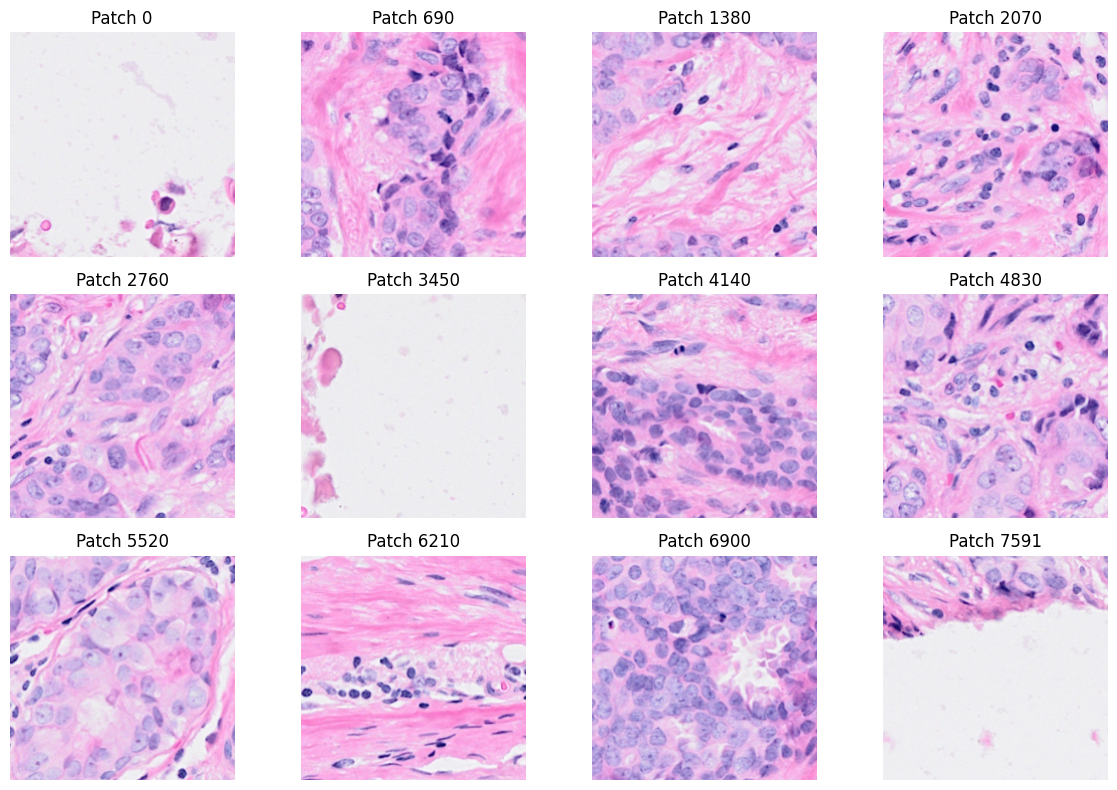

In [7]:
PATCH_DATASET_NAME = "img"

with h5py.File(PATCH_H5_PATH, "r") as f:
    patches = f[PATCH_DATASET_NAME]

    print("Patch dataset:", PATCH_DATASET_NAME)
    print("Shape:", patches.shape)
    print("Dtype:", patches.dtype)

    n_preview = min(12, patches.shape[0])
    indices = np.linspace(0, patches.shape[0] - 1, n_preview).astype(int)

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(indices):
        patch = patches[idx]

        # Handle channel-first format: C x H x W
        if patch.ndim == 3 and patch.shape[0] in [1, 3, 4]:
            patch = np.transpose(patch, (1, 2, 0))

        # Handle float images
        if patch.dtype != np.uint8:
            patch_min = patch.min()
            patch_max = patch.max()
            if patch_max > patch_min:
                patch = (255 * (patch - patch_min) / (patch_max - patch_min)).astype(np.uint8)
            else:
                patch = np.zeros_like(patch, dtype=np.uint8)

        plt.subplot(3, 4, i + 1)
        plt.imshow(patch)
        plt.title(f"Patch {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{SAMPLE_ID}_h5_patch_preview.png", dpi=300)
    plt.show()

This preview confirms that `patches/TENX95.h5` contains usable H&E image patches. The patches show clear histology morphology with the expected H&E staining pattern:
- pink regions  → eosin-stained cytoplasm / extracellular matrix / stroma
- purple regions → hematoxylin-stained nuclei
- white regions → background, empty space, or low-tissue area

### Checking patch count v/s spot count

In [8]:
with h5py.File(PATCH_H5_PATH, "r") as f:
    n_patches = f[PATCH_DATASET_NAME].shape[0]

n_spots = len(spot_metadata)

print("Number of patches:", n_patches)
print("Number of spots in metadata:", n_spots)
print("Difference:", n_patches - n_spots)

Number of patches: 7592
Number of spots in metadata: 11845
Difference: -4253


The patch-count check shows that the H5 patch file contains fewer image patches than the full spot metadata table.

This is expected as full spatial grid includes both tissue-containing spots + background spots.